# TrueCar Used-Car Dataset: Data Import, Cleaning, and EDA

These notes follow the same broad structure as the Ames Housing and Red Wine examples:
import the data, inspect variables, separate numeric/categorical fields, handle missing
values, create features, and prepare a modeling table.

## Learning Objectives

- Import a cleaned observational dataset created from web-scraped car listings.
- Distinguish raw listing fields from model-ready fields.
- Explore the response variable for regression: `sales_price`.
- Explore a classification label: `price_tier`.
- Build a reproducible preprocessing object for later predictive models.


## Hypotheses and Modeling Questions

The dataset supports both regression and classification questions.

**Regression question:** Can listing features predict a used car's sales price?

- Null idea: after accounting for sampling variation, vehicle attributes such as mileage,
  age, make, fuel type, and metro area do not explain meaningful variation in price.
- Alternative idea: at least some of these features explain meaningful variation in price.

**Classification question:** Can listing features classify a car as below, near, or above
market relative to TrueCar's average market price?

- Null idea: features do not classify `price_tier` better than a simple baseline.
- Alternative idea: the model improves on the baseline classification rule.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("../data")
CLEAN_DATA = DATA_DIR / "truecar_clean_combined.csv"
MODEL_DATA = DATA_DIR / "truecar_model_ready.csv"


## Import Data


In [2]:
if not CLEAN_DATA.exists():
    import sys
    sys.path.append("..")
    from truecar_data_pipeline import build_clean_dataset

    clean, report = build_clean_dataset(data_dir=DATA_DIR)
else:
    clean = pd.read_csv(CLEAN_DATA)

print(clean.shape)
clean.head()


(8629, 46)


,url,vin,title,year,make,model,trim,sales_price,average_market_price,price_tier,odometer_miles,vehicle_age,fuel_type,exterior,interior,dealer_info,dealer_city,dealer_state,dealer_distance_miles,source_city,source_state,source_metro,feature_count,standard_feature_count,seller_notes,price_description,listed_since,stock_number,mileage_listed,list_price_displayed,mileage,list_price,average_list_price,price_range_excellent,price_range_great,price_range_fair,price_range_high,epa_range,city_state,distance,city,state,year_from_title,make_from_title,model_from_title,trim_from_title
0,https://www.truecar.com/used-cars-for-sale/listing/19UDE2F78JA010128/2018-acura-ilx/?position=29&returnTo=%2Fused-ca...,19UDE2F78JA010128,Used 2018 Acura ILX with Premium Package,2018,Acura,ILX,with Premium Package,18000.0,19571.0,below_market,60784,8,Gas,Crystal Black Pearl,Ebony,Automax Preowned Marlborough,Marlborough,MA,26.0,Boston,MA,boston_ma,0,0,Only 61k Miles - Premium Edition - Crystal Black Pearl exterior on Ebony Black Leather interior with Navigation / GP...,"The list price of $18,000 for this 2018 Acura ILX is an excellent price! The average list price for similar models i...",Listed 4 days ago,010128T,"60,784 miles","$18,000","Marlborough, MA (26 miles away)","$18,000","$19,571","Below $18,592","$18,592 - $19,375","$19,375 - $20,158","Above $20,158",NaN,NaN,NaN,NaN,NaN,2018,Acura,ILX,with Premium Package
1,https://www.truecar.com/used-cars-for-sale/listing/19UDE2F8XNA008248/2022-acura-ilx/?position=15&returnTo=%2Fused-ca...,19UDE2F8XNA008248,Used 2022 Acura ILX Sedan w/Premium/A-SPEC Package,2022,Acura,ILX,Sedan w/Premium/A-SPEC Package,25499.0,26042.0,near_market,26314,4,Gas,Platinum White Pearl,Red,Acura of Boston,Brighton,MA,12.0,Boston,MA,boston_ma,0,0,Recent Arrival! Platinum White Pearl 2022 Acura ILX Premium and A-SPEC Packages 2. 4L I4 DOHC i-VTEC 16V 8-Speed Dua...,"The list price of $25,499 for this 2022 Acura ILX is a great price! The average list price for similar models is $26...",Listed 8 days ago,AS1040A,"26,314 miles","$25,499","Brighton, MA (12 miles away)","$25,499","$26,042","Below $24,739","$24,739 - $25,781","$25,781 - $26,822","Above $26,822",NaN,NaN,NaN,NaN,NaN,2022,Acura,ILX,Sedan w/Premium/A-SPEC Package
2,https://www.truecar.com/used-cars-for-sale/listing/19UDE4H60SA002994/2025-acura-integra/?position=21&returnTo=%2Fuse...,19UDE4H60SA002994,Used 2025 Acura Integra A-Spec Technology Package CVT,2025,Acura,Integra,A-Spec Technology Package CVT,35399.0,35812.0,near_market,4617,1,Gas,Platinum White Pearl,Ebony,San Francisco Honda,San Francisco,CA,2688.0,San Francisco,CA,san-francisco_ca,0,0,"Acura Certified Pre-Owned, Acura Watch, Back-Up Camera, Climate Control, Apple Car Play/ Android Auto, Bluetooth Han...","The list price of $35,399 for this 2025 Acura Integra is a great price! The average list price for similar models is...",Listed 40 days ago,51E02508,"4,617 miles","$35,399","San Francisco, CA (2688 miles away)","$35,399","$35,812","Below $34,021","$34,021 - $35,453","$35,453 - $36,886","Above $36,886",NaN,NaN,NaN,NaN,NaN,2025,Acura,Integra,A-Spec Technology Package CVT
3,https://www.truecar.com/used-cars-for-sale/listing/19UDE4H62SA002995/2025-acura-integra/?position=0&returnTo=%2Fused...,19UDE4H62SA002995,Used 2025 Acura Integra A-Spec Technology Package CVT,2025,Acura,Integra,A-Spec Technology Package CVT,34680.0,35072.0,near_market,2551,1,Gas,Platinum White Pearl,Ebony,Oakland Acura,Oakland,CA,2678.0,San Francisco,CA,san-francisco_ca,0,0,Certified. FWD CVT 1. 5L I4 DOHC 16V This Integra is in Excellent Condition and is Acura CERTIFIED! It has very low ...,"The list price of $34,680 for this 2025 Acura Integra is a great price! The average list price for similar models is...",Listed 38 days ago,13640L,"2,551 miles","$34,680","Oakland, CA (2678 miles away)","$34,680","$35,072","Below $31,864","$31,864 - $35,072","$35,072 - $38,280","Above $38,280",NaN,NaN,NaN,NaN,NaN,2025,Acura,Integra,A-Spec Technology Package C

## Basic Overview


In [3]:
overview = pd.DataFrame({
    "dtype": clean.dtypes.astype(str),
    "missing": clean.isna().sum(),
    "missing_rate": clean.isna().mean().round(3),
    "unique_values": clean.nunique(dropna=True),
}).sort_values(["missing_rate", "unique_values"], ascending=[False, False])

overview.head(25)


,dtype,missing,missing_rate,unique_values
city_state,float64,8629,1.000,0
distance,float64,8629,1.000,0
city,float64,8629,1.000,0
state,float64,8629,1.000,0
epa_range,str,7958,0.922,121
seller_notes,str,535,0.062,6706
stock_number,str,303,0.035,8302
price_description,str,180,0.021,8449
price_range_great,str,180,0.021,7954
price_range_fair,str,180,0.021,7950


In [4]:
numeric_vars = clean.select_dtypes(include=np.number).columns.tolist()
categorical_vars = clean.select_dtypes(exclude=np.number).columns.tolist()

print(f"There are {len(numeric_vars)} numeric variables and {len(categorical_vars)} categorical/text variables.")
print("Numeric variables:", numeric_vars)


There are 13 numeric variables and 33 categorical/text variables.
Numeric variables: ['year', 'sales_price', 'average_market_price', 'odometer_miles', 'vehicle_age', 'dealer_distance_miles', 'feature_count', 'standard_feature_count', 'city_state', 'distance', 'city', 'state', 'year_from_title']


## Response Variable: Sales Price


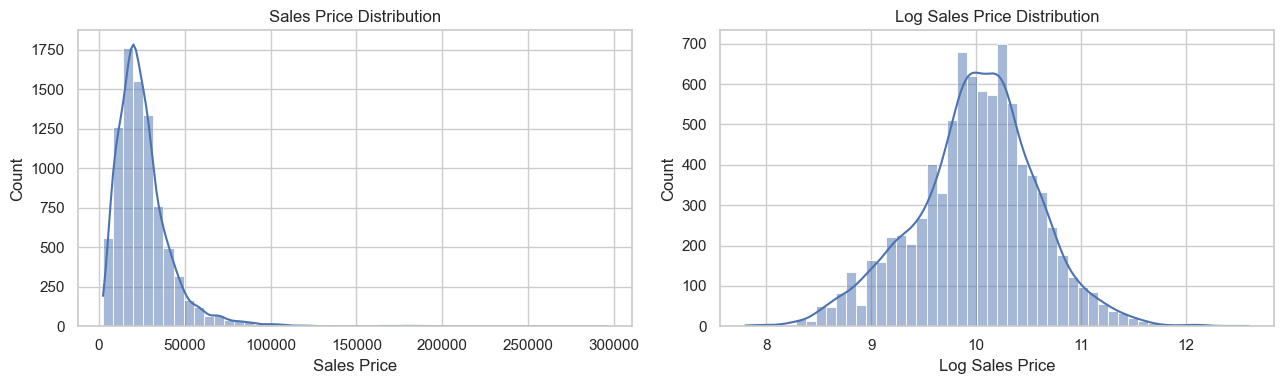

In [5]:
clean["log_sales_price"] = np.log(clean["sales_price"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(clean["sales_price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Sales Price Distribution")
axes[0].set_xlabel("Sales Price")

sns.histplot(clean["log_sales_price"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log Sales Price Distribution")
axes[1].set_xlabel("Log Sales Price")
plt.tight_layout()


The raw price distribution is right-skewed, which is common for prices and incomes.
A log transformation often makes linear modeling more stable and makes coefficient
interpretation closer to percent changes.


## Market and Vehicle Coverage


In [6]:
metro_summary = (
    clean.groupby("source_metro")
    .agg(
        rows=("url", "count"),
        median_price=("sales_price", "median"),
        median_miles=("odometer_miles", "median"),
        unique_makes=("make", "nunique"),
    )
    .sort_values("rows", ascending=False)
)
metro_summary


,rows,median_price,median_miles,unique_makes
source_metro,,,,
chicago_il,1278,23988.0,46598.0,41
san-francisco_ca,1245,22998.0,48652.0,39
atlanta_ga,1230,19998.0,62030.0,41
austin_tx,1230,27923.0,49482.5,35
seattle_wa,1225,20998.0,53778.0,41
boston_ma,1218,23282.0,46496.5,36
detroit_mi,1203,20375.0,55467.0,38


In [7]:
make_summary = (
    clean.groupby("make")
    .agg(rows=("url", "count"), median_price=("sales_price", "median"))
    .sort_values("rows", ascending=False)
    .head(20)
)
make_summary


,rows,median_price
make,,
Ford,1168,23968.5
Chevrolet,851,20677.0
Toyota,740,22998.0
Jeep,544,24549.5
Nissan,483,17895.0
Honda,459,21991.0
BMW,434,31992.5
Mercedes-Benz,407,28998.0
Hyundai,283,19595.0


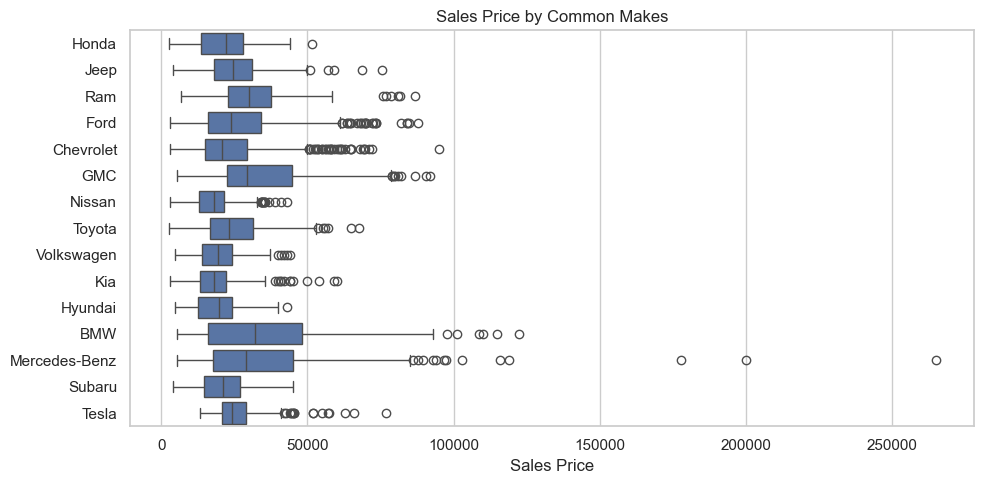

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
top_makes = clean["make"].value_counts().head(15).index
sns.boxplot(data=clean[clean["make"].isin(top_makes)], x="sales_price", y="make", ax=ax)
ax.set_title("Sales Price by Common Makes")
ax.set_xlabel("Sales Price")
ax.set_ylabel("")
plt.tight_layout()


## Correlation Analysis for Numeric Variables


,sales_price,log_sales_price,odometer_miles,vehicle_age,average_market_price,dealer_distance_miles,feature_count,standard_feature_count
sales_price,1.000000,0.882452,-0.528326,-0.505479,0.992671,0.029721,NaN,NaN
log_sales_price,0.882452,1.000000,-0.687820,-0.699026,0.867007,-0.004103,NaN,NaN
odometer_miles,-0.528326,-0.687820,1.000000,0.677946,-0.508537,0.047042,NaN,NaN
vehicle_age,-0.505479,-0.699026,0.677946,1.000000,-0.482316,0.081167,NaN,NaN
average_market_price,0.992671,0.867007,-0.508537,-0.482316,1.000000,0.038714,NaN,NaN
dealer_distance_miles,0.029721,-0.004103,0.047042,0.081167,0.038714,1.000000,NaN,NaN
feature_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_feature_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


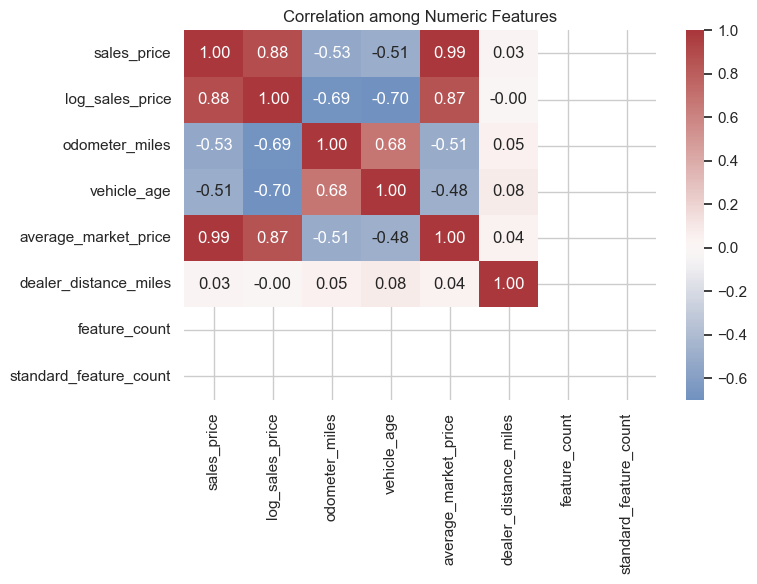

In [9]:
corr_cols = [
    "sales_price",
    "log_sales_price",
    "odometer_miles",
    "vehicle_age",
    "average_market_price",
    "dealer_distance_miles",
    "feature_count",
    "standard_feature_count",
]
corr_cols = [c for c in corr_cols if c in clean.columns]
corr = clean[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation among Numeric Features")
plt.tight_layout()
corr


## Classification Target Balance


In [10]:
price_tier_counts = clean["price_tier"].value_counts(dropna=False).rename_axis("price_tier").to_frame("rows")
price_tier_counts["rate"] = (price_tier_counts["rows"] / len(clean)).round(3)
price_tier_counts


,rows,rate
price_tier,,
below_market,5742,0.665
near_market,2620,0.304
NaN,180,0.021
above_market,87,0.010


The target is imbalanced. This matters because a model can appear accurate by predicting
the majority class. In the classification notebook, we will use stratified sampling,
balanced class weights, and macro-averaged metrics.


## Feature Preparation for Later Models


In [11]:
modeling_columns = [
    "sales_price", "price_tier", "year", "vehicle_age", "make", "model", "trim",
    "odometer_miles", "fuel_type", "exterior", "interior", "dealer_state",
    "dealer_distance_miles", "source_metro", "feature_count", "standard_feature_count",
]

model_df = clean[[c for c in modeling_columns if c in clean.columns]].copy()
model_df = model_df.dropna(subset=["sales_price", "odometer_miles", "vehicle_age", "make", "model"])
model_df.to_csv(MODEL_DATA, index=False)

print(model_df.shape)
model_df.head()


(8629, 16)


,sales_price,price_tier,year,vehicle_age,make,model,trim,odometer_miles,fuel_type,exterior,interior,dealer_state,dealer_distance_miles,source_metro,feature_count,standard_feature_count
0,18000.0,below_market,2018,8,Acura,ILX,with Premium Package,60784,Gas,Crystal Black Pearl,Ebony,MA,26.0,boston_ma,0,0
1,25499.0,near_market,2022,4,Acura,ILX,Sedan w/Premium/A-SPEC Package,26314,Gas,Platinum White Pearl,Red,MA,12.0,boston_ma,0,0
2,35399.0,near_market,2025,1,Acura,Integra,A-Spec Technology Package CVT,4617,Gas,Platinum White Pearl,Ebony,CA,2688.0,san-francisco_ca,0,0
3,34680.0,near_market,2025,1,Acura,Integra,A-Spec Technology Package CVT,2551,Gas,Platinum White Pearl,Ebony,CA,2678.0,san-francisco_ca,0,0
4,28883.0,near_market,2023,3,Acura,Integra,CVT w/A-Spec Technology Package,41138,Gas,Platinum White Pearl,Red,TX,1691.0,austin_tx,0,0


## Wrap-Up

The modeling table now contains a continuous target (`sales_price`) and a categorical target
(`price_tier`). The next notebooks use this table to build regression and classification
models, while retaining the statistical-learning ideas from the Ames and Red Wine notes:
hypotheses, train/test splits, likelihood, AIC/BIC, diagnostics, and predictive evaluation.
